# Feature Engineering y Splits (Stress Test)

Notebook maestro para validar el dataset de entrenamiento y crear el split temporal de stress test. El corte 2021-01-01 permite evaluar la robustez del modelo ante la disrupcion internacional (incluye el shock de Ucrania).

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

base_dir = Path.cwd()
data_path = None
search_roots = [base_dir, *base_dir.parents]

for root in search_roots:
    candidate = root / "data" / "processed" / "dataset_entrenamiento_final.csv"
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    searched = [str(root / "data" / "processed" / "dataset_entrenamiento_final.csv") for root in search_roots]
    raise FileNotFoundError("Dataset not found. Searched:\n" + "\n".join(searched))

print("using data_path:", data_path.resolve())
df = pd.read_csv(data_path, parse_dates=["date"])
print("shape:", df.shape)

using data_path: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\processed\dataset_entrenamiento_final.csv
shape: (7047, 76)


## 1. Sanity Check del Dataset
Validamos presencia de identificadores, variables estaticas (puertos/coords) y lags.

Tambien confirmamos que no existen columnas contemporaneas de precio o clima (sin lag).

In [12]:
expected_core = ["date", "provincia", "cereal_predominante", "precio_provincial_TARGET_H1"]
static_candidates = [
    "latitud", "longitud", "dist_puerto_min_km", "presion_combustible_puerto"
 ]
lag_candidates = [c for c in df.columns if "_lag_" in c]

missing_core = [c for c in expected_core if c not in df.columns]
missing_static = [c for c in static_candidates if c not in df.columns]

print("columns count:", len(df.columns))
print("missing core columns:", missing_core if missing_core else "none")
print("missing static columns:", missing_static if missing_static else "none")
print("lag columns count:", len(lag_candidates))

allowed_nonlag = {
    "precip_relative_shock",
    "month_sin", "month_cos",
    "fase_siembra", "fase_entre", "fase_cosecha",
    "latitud", "longitud", "dist_puerto_min_km", "presion_combustible_puerto",
    "sup_cereal_predominante", "total_sup_trigo", "total_sup_cebada",
    "precio_vecinos_media_lag1",
}

price_contemporaneous = [
    c for c in df.columns
    if ("precio" in c)
    and ("_lag_" not in c)
    and ("TARGET" not in c)
    and (c not in allowed_nonlag)
 ]
climate_contemporaneous = [
    c for c in df.columns
    if ("temp_" in c or "precip_" in c or "z_clima_" in c)
    and ("_lag_" not in c)
    and (c not in allowed_nonlag)
 ]

if not price_contemporaneous:
    print("OK: no contemporaneous price columns detected.")
else:
    print("WARNING: contemporaneous price columns detected:", price_contemporaneous)

if not climate_contemporaneous:
    print("OK: no contemporaneous climate columns detected.")
else:
    print("WARNING: contemporaneous climate columns detected:", climate_contemporaneous)

columns count: 76
missing core columns: none
missing static columns: ['latitud', 'longitud']
lag columns count: 48
OK: no contemporaneous climate columns detected.


## 1b. Consistencia mensual de targets
Verificamos que cada mes tenga el mismo numero de targets y el mismo set de provincia/cereal. Tambien listamos, por mes, los cereales presentes en cada provincia.

In [13]:
df_month = df.copy()
df_month["month"] = df_month["date"].dt.to_period("M").dt.to_timestamp()
df_month["provincia_cereal"] = (
    df_month["provincia"].astype(str) + " | " + df_month["cereal_predominante"].astype(str)
 )

pairs_by_month = (
    df_month.groupby(["month", "provincia"])
    ["cereal_predominante"]
    .apply(lambda s: sorted(set(s)))
    .reset_index(name="cereales")
 )
pairs_by_month["n_cereales"] = pairs_by_month["cereales"].apply(len)

monthly_counts = (
    df_month.groupby("month")
    .agg(
        targets=("precio_provincial_TARGET_H1", "size"),
        provincias=("provincia", "nunique"),
        provincia_cereal_pairs=("provincia_cereal", "nunique"),
    )
    .reset_index()
    .sort_values("month")
 )

print("months count:", monthly_counts["month"].nunique())
print("date range:", monthly_counts["month"].min(), "->", monthly_counts["month"].max())
print("targets/provincias por mes:")
print(monthly_counts.head(12))

mismatch = monthly_counts[monthly_counts["targets"] != monthly_counts["provincia_cereal_pairs"]]
if mismatch.empty:
    print("OK: targets == provincia/cereal pairs for all months.")
else:
    print("WARNING: targets != provincia/cereal pairs in months:")
    print(mismatch)

baseline = monthly_counts.iloc[0][["targets", "provincias", "provincia_cereal_pairs"]]
diff_months = monthly_counts[
    (monthly_counts["targets"] != baseline["targets"])
    | (monthly_counts["provincias"] != baseline["provincias"])
    | (monthly_counts["provincia_cereal_pairs"] != baseline["provincia_cereal_pairs"])
 ]
if diff_months.empty:
    print("OK: all months have identical counts.")
else:
    print("WARNING: months with different counts:")
    print(diff_months)

base_month = monthly_counts["month"].min()
base_pairs = set(
    df_month[df_month["month"] == base_month][["provincia", "cereal_predominante"]]
    .itertuples(index=False, name=None)
 )

diff_rows = []
for month in monthly_counts["month"]:
    month_pairs = set(
        df_month[df_month["month"] == month][["provincia", "cereal_predominante"]]
        .itertuples(index=False, name=None)
    )
    missing = base_pairs - month_pairs
    extra = month_pairs - base_pairs
    if missing or extra:
        diff_rows.append({
            "month": month,
            "missing_pairs": len(missing),
            "extra_pairs": len(extra),
        })

if diff_rows:
    diff_df = pd.DataFrame(diff_rows)
    print("months with differing provincia/cereal sets:")
    print(diff_df)
else:
    print("OK: all months share the same provincia/cereal set.")

prov_two = pairs_by_month[pairs_by_month["n_cereales"] > 1]
if prov_two.empty:
    print("No provincias con mas de un cereal en el mismo mes.")
else:
    prov_two_counts = prov_two.groupby("month").size().reset_index(name="provincias_2_cereales")
    print("provincias con 2+ cereales por mes (muestra):")
    print(prov_two_counts.head(12))
    print("\nCereales por provincia y mes (muestra):")
    print(prov_two.head(20))

months count: 243
date range: 2005-07-01 00:00:00 -> 2025-09-01 00:00:00
targets/provincias por mes:
        month  targets  provincias  provincia_cereal_pairs
0  2005-07-01       29          22                      29
1  2005-08-01       29          22                      29
2  2005-09-01       29          22                      29
3  2005-10-01       29          22                      29
4  2005-11-01       29          22                      29
5  2005-12-01       29          22                      29
6  2006-01-01       29          22                      29
7  2006-02-01       29          22                      29
8  2006-03-01       29          22                      29
9  2006-04-01       29          22                      29
10 2006-05-01       29          22                      29
11 2006-06-01       29          22                      29
OK: targets == provincia/cereal pairs for all months.
OK: all months have identical counts.
OK: all months share the same provincia/

## 2. Validacion del Target
El target oficial es `precio_provincial_TARGET_H1`. Debe estar completo y reflejar la distribucion esperada.

target nulls: 0
count    7047.000000
mean       21.886294
std         5.735732
min        12.404120
25%        18.284267
50%        20.873623
75%        24.491656
max        42.362514
Name: precio_provincial_TARGET_H1, dtype: float64


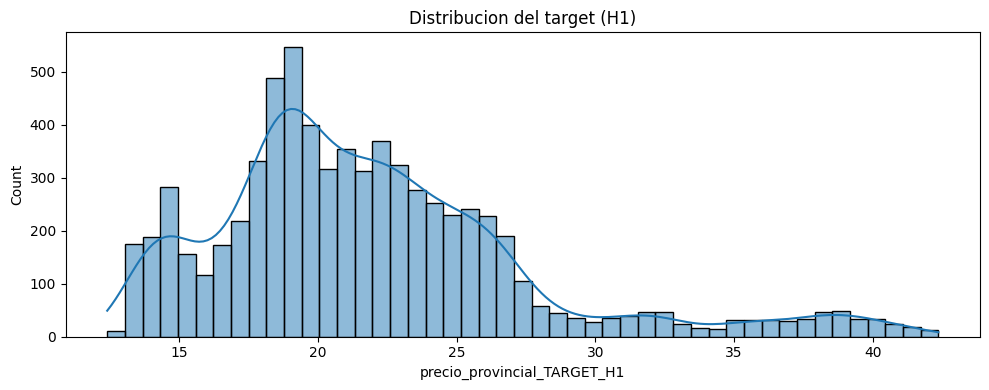

In [14]:
target_col = "precio_provincial_TARGET_H1"
if target_col not in df.columns:
    raise ValueError(f"Missing target column: {target_col}")

target_nulls = df[target_col].isna().sum()
print("target nulls:", target_nulls)
print(df[target_col].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df[target_col].dropna(), kde=True)
plt.title("Distribucion del target (H1)")
plt.tight_layout()
plt.show()

## 3. Split Temporal (Stress Test 2021)
Corte en `2021-01-01` para separar regimenes historicos y validar generalizacion en crisis internacionales.

train rows: 5394
test rows: 1653


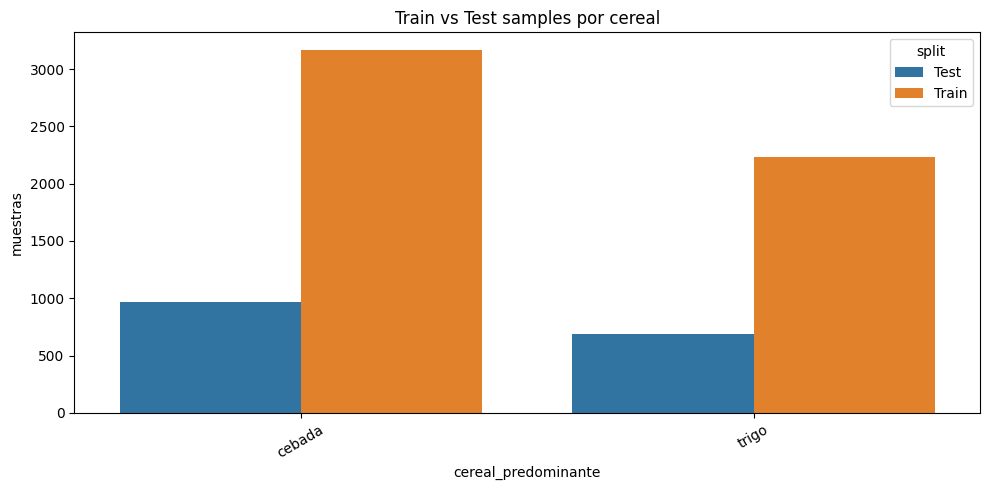

In [15]:
cutoff = pd.Timestamp("2021-01-01")
end_test = pd.Timestamp("2025-12-31")

df_train = df[df["date"] < cutoff].copy()
df_test = df[(df["date"] >= cutoff) & (df["date"] <= end_test)].copy()

print("train rows:", len(df_train))
print("test rows:", len(df_test))

if "cereal_predominante" in df.columns:
    counts = (
        pd.concat([
            df_train.assign(split="Train"),
            df_test.assign(split="Test"),
        ])
        .groupby(["split", "cereal_predominante"])
        .size()
        .reset_index(name="count")
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=counts, x="cereal_predominante", y="count", hue="split")
    plt.title("Train vs Test samples por cereal")
    plt.xlabel("cereal_predominante")
    plt.ylabel("muestras")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 4. Estructuras para Modelado
Separamos `X` y `y` excluyendo metadatos, pero preservamos esas columnas para analisis posterior.

In [16]:
metadata_cols = ["date", "provincia", "cereal_predominante"]

X_train = df_train.drop(columns=metadata_cols + [target_col])
y_train = df_train[target_col].copy()
X_test = df_test.drop(columns=metadata_cols + [target_col])
y_test = df_test[target_col].copy()

meta_train = df_train[metadata_cols].copy()
meta_test = df_test[metadata_cols].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5394, 72)
X_test shape: (1653, 72)
y_train shape: (5394,)
y_test shape: (1653,)


## 5. Exportacion de Splits (Blindado)
Se guardan los CSV finales para uso directo en modelado.

In [17]:
splits_dir = data_path.parent.parent / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)

train_path = splits_dir / "train_v2_blindado.csv"
test_path = splits_dir / "test_v2_blindado.csv"

df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path, index=False)

print("saved:", train_path.resolve())
print("saved:", test_path.resolve())

saved: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\splits\train_v2_blindado.csv
saved: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\splits\test_v2_blindado.csv
